# (1) CosmoHydro_emu vs Subgrid_emu — common statistics at fixed cosmology

**Question:** With CosmoHydro's cosmology fixed to the value used by the Subgrid suite
(both suites share the same fixed ΛCDM cosmology, see `../fixed_parameters.txt`),
how do the common emulated quantities compare?

| | Subgrid_emu | CosmoHydro_emu |
|---|---|---|
| Params | 5 subgrid | 5 subgrid + (ωₘ, σ₈) |
| Box | 128 h⁻¹Mpc (2×512³), 2p: 256 h⁻¹Mpc | 400 h⁻¹Mpc (2×1024³) |
| Redshift | z = 0 only | multi-z |

Common statistics: **GSMF, fGas, CGD, CSFR, Pk-ratio** (called `Pk` in subgrid_emu).
The 2-parameter large-box variants (`CGD_2p`, `fGas_2p`, `Pk_2p`) are also compared.
All comparisons here are at **z = 0**, with CosmoHydro evaluated at the fiducial cosmology
ωₘₘ = 0.14176, σ₈ = 0.8102 (the cosmology of the subgrid training suite).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

import cosmohydro_emu as ce
import subgrid_emu as sge

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

## Fixed parameters (loaded from `../fixed_parameters.txt`)

In [2]:
def load_fixed_params(path='../fixed_parameters.txt'):
    params = {}
    with open(path) as f:
        for line in f:
            line = line.split('#')[0].strip()
            if '=' in line:
                key, val = [s.strip() for s in line.split('=')]
                try:
                    params[key] = float(val)
                except ValueError:
                    params[key] = val
    return params

FP = load_fixed_params()

# [kappa_w, e_w, M_seed/1e6, v_kin/1e4, eps_kin/1e1] -- Frontier-E adopted values
P5 = [FP['kappa_w'], FP['e_w'], FP['M_seed'], FP['v_kin'], FP['epsilon_kin']]
# CosmoHydro takes the same 5 + [omega_m, sigma_8]
P7 = P5 + [FP['omega_m'], FP['sigma_8']]
# 2-parameter (large-box) models take [v_kin, eps_kin]
P2 = [FP['v_kin'], FP['epsilon_kin']]

print('P5 =', P5)
print('P7 =', P7)

P5 = [3.0, 0.5, 0.8, 0.5, 0.13]
P7 = [3.0, 0.5, 0.8, 0.5, 0.13, 0.14176, 0.8102]


## Fiducial comparison of the five common statistics

Solid: emulator means. Bands: CosmoHydro ±2σ (GP std, delta-method) and Subgrid ±2σ.
Bottom panels: ratio CosmoHydro / Subgrid on the overlapping x-range.

In [3]:
COMMON = [('GSMF', 'GSMF'), ('fGas', 'fGas'), ('CGD', 'CGD'),
          ('CSFR', 'CSFR'), ('Pk-ratio', 'Pk')]

# cache predictions
pred = {}
for ch_name, sg_name in COMMON:
    ch_emu = ce.load_emulator(ch_name)
    ch_mean, ch_std = ch_emu.predict(P7, z=0.0)
    ch_x, _ = ce.get_x_grid(ch_name)

    sg_emu = sge.load_emulator(sg_name)
    sg_mean, sg_std = sg_emu.predict(P5)
    sg_x, _ = sge.get_x_grid(sg_name)

    pred[ch_name] = dict(ch_x=np.asarray(ch_x), ch_mean=ch_mean, ch_std=ch_std,
                         sg_x=np.asarray(sg_x), sg_mean=sg_mean, sg_std=sg_std)
    print(f'{ch_name:9s}  CH grid {len(ch_x):4d} pts  |  SG ({sg_name}) grid {len(sg_x):4d} pts')

GSMF       CH grid   16 pts  |  SG (GSMF) grid   16 pts
fGas       CH grid    3 pts  |  SG (fGas) grid    8 pts


CGD        CH grid   19 pts  |  SG (CGD) grid   19 pts
CSFR       CH grid  625 pts  |  SG (CSFR) grid  655 pts


Pk-ratio   CH grid  511 pts  |  SG (Pk) grid  255 pts


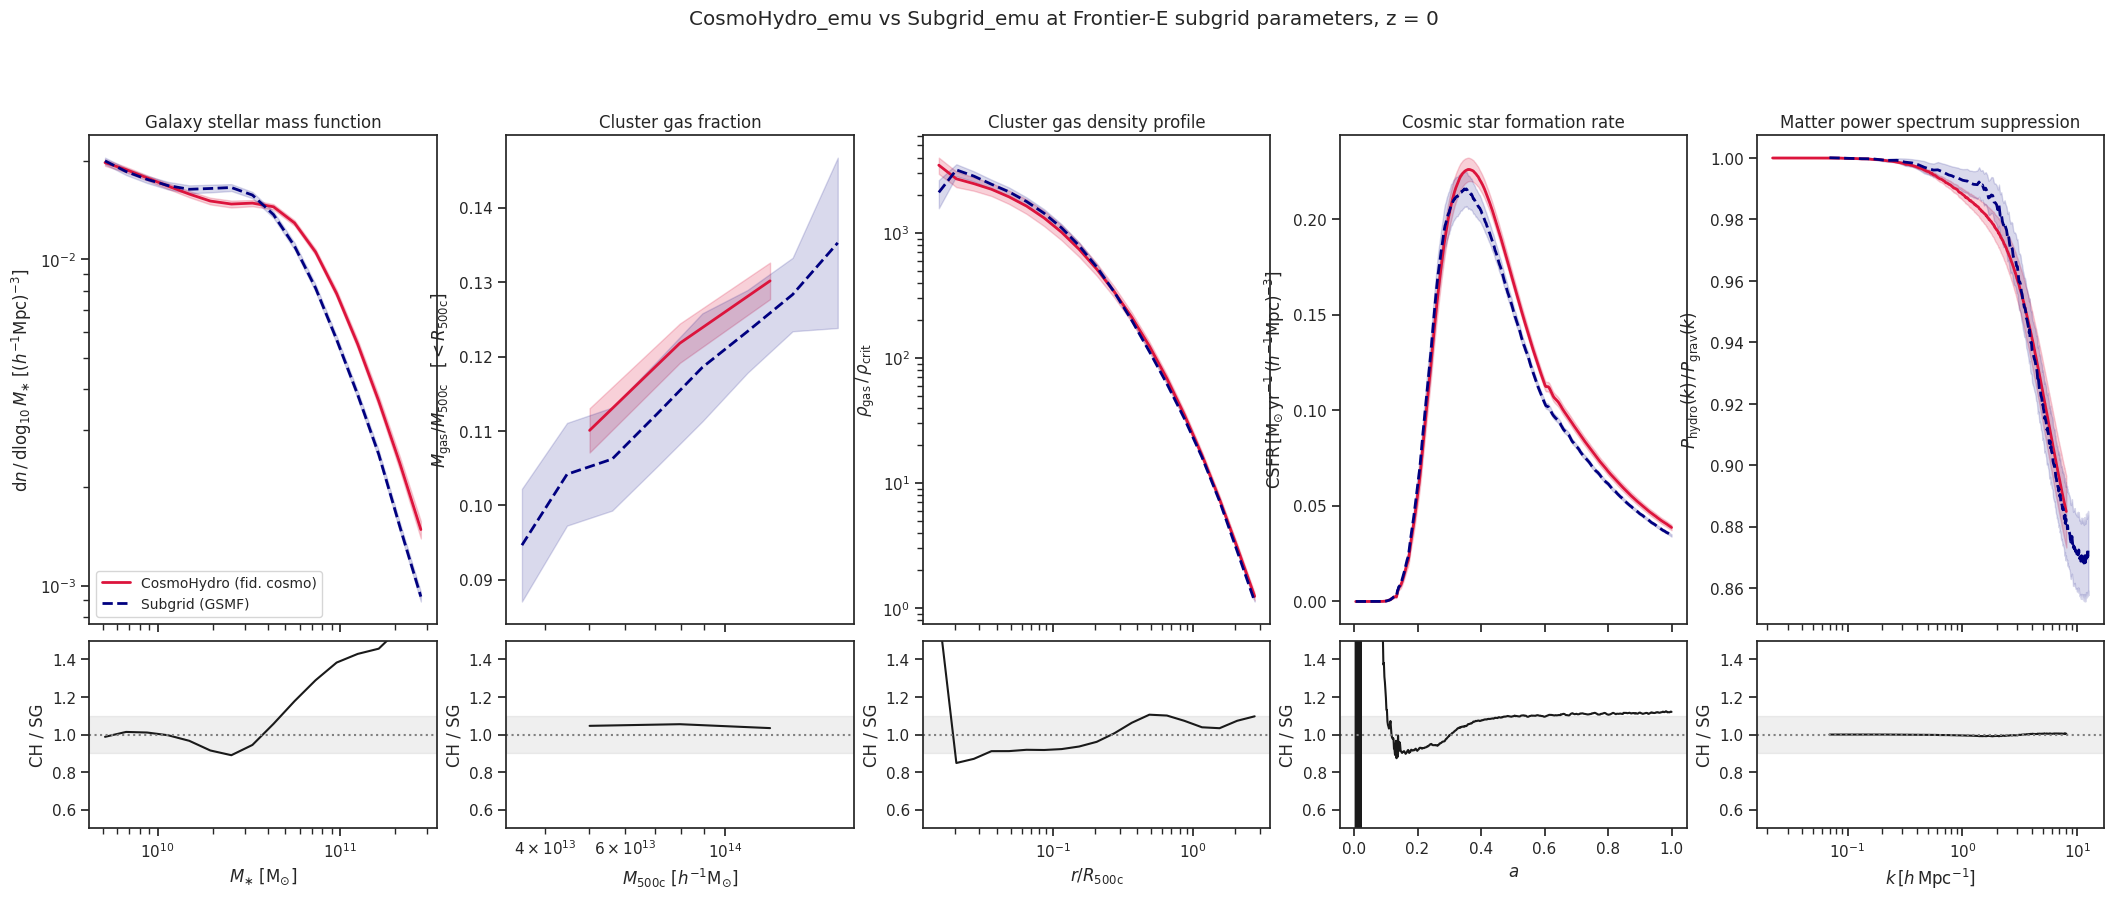

In [4]:
def ratio_on_overlap(x1, y1, x2, y2, logx=True):
    """Interpolate y2 onto x1 (log-x interpolation) over the overlapping range,
    return (x_overlap, y1/y2_interp)."""
    lo, hi = max(x1.min(), x2.min()), min(x1.max(), x2.max())
    m = (x1 >= lo) & (x1 <= hi)
    if logx:
        y2i = np.interp(np.log10(x1[m]), np.log10(x2), y2)
    else:
        y2i = np.interp(x1[m], x2, y2)
    return x1[m], y1[m] / y2i

fig, axes = plt.subplots(2, 5, figsize=(26, 9), sharex='col',
                         gridspec_kw={'height_ratios': [2.6, 1], 'hspace': 0.05})

for j, (ch_name, sg_name) in enumerate(COMMON):
    d = pred[ch_name]
    info = ce.get_plot_info(ch_name)
    ax, axr = axes[0, j], axes[1, j]

    ax.plot(d['ch_x'], d['ch_mean'], color='crimson', lw=2,
            label='CosmoHydro (fid. cosmo)')
    ax.fill_between(d['ch_x'], d['ch_mean'] - 2*d['ch_std'],
                    d['ch_mean'] + 2*d['ch_std'], color='crimson', alpha=0.2)
    ax.plot(d['sg_x'], d['sg_mean'], color='navy', lw=2, ls='--',
            label=f'Subgrid ({sg_name})')
    ax.fill_between(d['sg_x'], d["sg_mean"] - 2*d["sg_std"], d["sg_mean"] + 2*d["sg_std"],
                    color='navy', alpha=0.15)

    ax.set_xscale(info['xscale']); ax.set_yscale(info['yscale'])
    ax.set_title(info['title']); ax.set_ylabel(info['ylabel'])
    if j == 0:
        ax.legend(fontsize=10)

    logx = info['xscale'] == 'log'
    xo, r = ratio_on_overlap(d['ch_x'], d['ch_mean'], d['sg_x'], d['sg_mean'], logx=logx)
    axr.plot(xo, r, color='k', lw=1.5)
    axr.axhline(1, color='gray', ls=':')
    axr.axhspan(0.9, 1.1, color='gray', alpha=0.12)
    axr.set_ylim(0.5, 1.5)
    axr.set_xlabel(info['xlabel']); axr.set_ylabel('CH / SG')

plt.suptitle('CosmoHydro_emu vs Subgrid_emu at Frontier-E subgrid parameters, z = 0', y=1.02)
plt.tight_layout(); plt.show()

## Large-box 2-parameter variants (`CGD_2p`, `fGas_2p`, `Pk_2p`)

The 2p subgrid models were trained on 256 h⁻¹Mpc boxes (closer to CosmoHydro's 400 h⁻¹Mpc),
varying only (v_kin, ε_kin) with the wind/seed parameters held at the Phase-1 best fit —
exactly the values in `P5`, so the comparison is apples-to-apples.

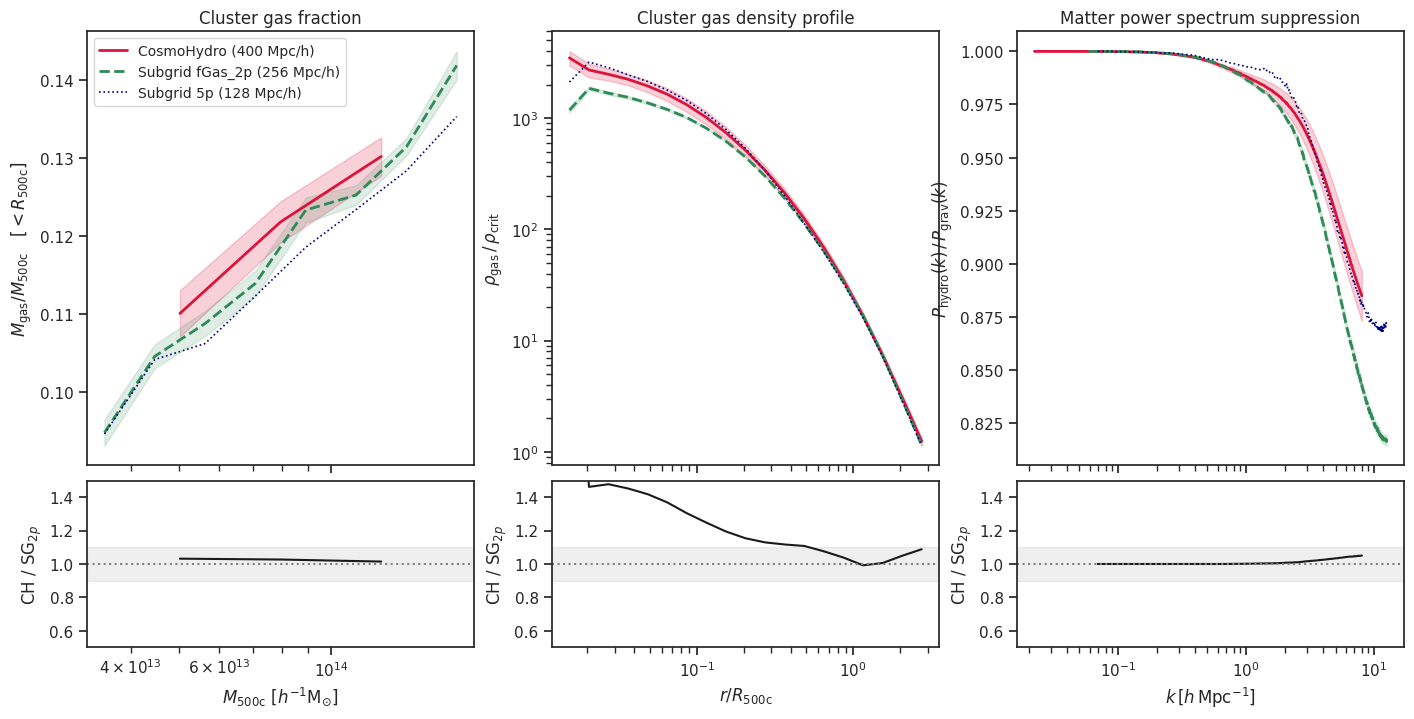

In [5]:
COMMON_2P = [('fGas', 'fGas_2p'), ('CGD', 'CGD_2p'), ('Pk-ratio', 'Pk_2p')]

fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex='col',
                         gridspec_kw={'height_ratios': [2.6, 1], 'hspace': 0.05})

for j, (ch_name, sg_name) in enumerate(COMMON_2P):
    d = pred[ch_name]
    sg_emu = sge.load_emulator(sg_name)
    sg_mean, sg_std = sg_emu.predict(P2)
    sg_x, _ = sge.get_x_grid(sg_name)
    sg_x = np.asarray(sg_x)
    info = ce.get_plot_info(ch_name)
    ax, axr = axes[0, j], axes[1, j]

    ax.plot(d['ch_x'], d['ch_mean'], color='crimson', lw=2, label='CosmoHydro (400 Mpc/h)')
    ax.fill_between(d['ch_x'], d['ch_mean'] - 2*d['ch_std'],
                    d['ch_mean'] + 2*d['ch_std'], color='crimson', alpha=0.2)
    ax.plot(sg_x, sg_mean, color='seagreen', lw=2, ls='--', label=f'Subgrid {sg_name} (256 Mpc/h)')
    ax.fill_between(sg_x, sg_mean - 2*sg_std, sg_mean + 2*sg_std, color='seagreen', alpha=0.15)
    ax.plot(d['sg_x'], d['sg_mean'], color='navy', lw=1.2, ls=':', label='Subgrid 5p (128 Mpc/h)')

    ax.set_xscale(info['xscale']); ax.set_yscale(info['yscale'])
    ax.set_title(info['title']); ax.set_ylabel(info['ylabel'])
    if j == 0:
        ax.legend(fontsize=10)

    logx = info['xscale'] == 'log'
    xo, r = ratio_on_overlap(d['ch_x'], d['ch_mean'], sg_x, sg_mean, logx=logx)
    axr.plot(xo, r, color='k', lw=1.5)
    axr.axhline(1, color='gray', ls=':')
    axr.axhspan(0.9, 1.1, color='gray', alpha=0.12)
    axr.set_ylim(0.5, 1.5)
    axr.set_xlabel(info['xlabel']); axr.set_ylabel('CH / SG$_{2p}$')

plt.tight_layout(); plt.show()

## Agreement across the subgrid parameter space

Vary one subgrid parameter at a time across the range common to both packages
(others held at the Frontier-E values), and compare the two emulators for
GSMF and Pk-ratio — the most observationally relevant statistics.

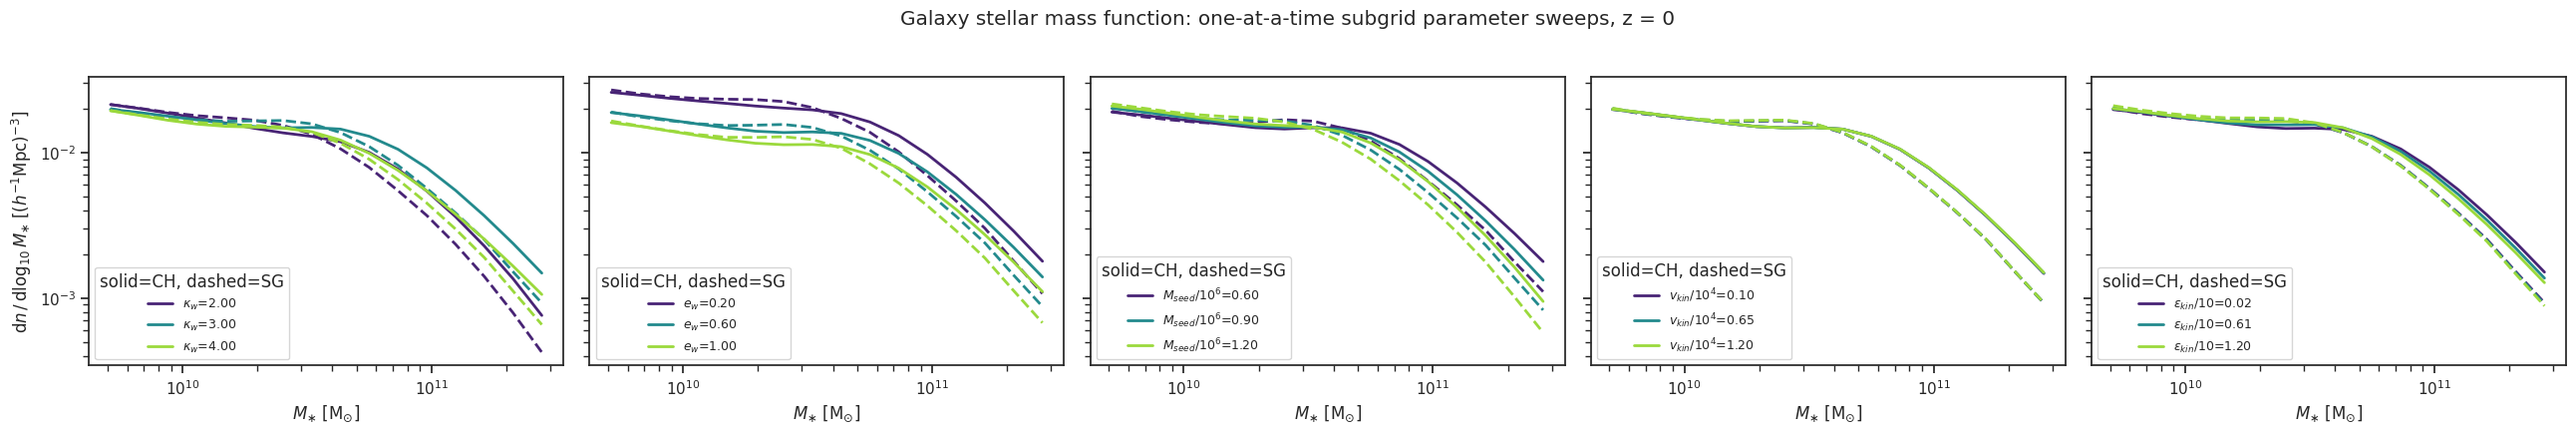

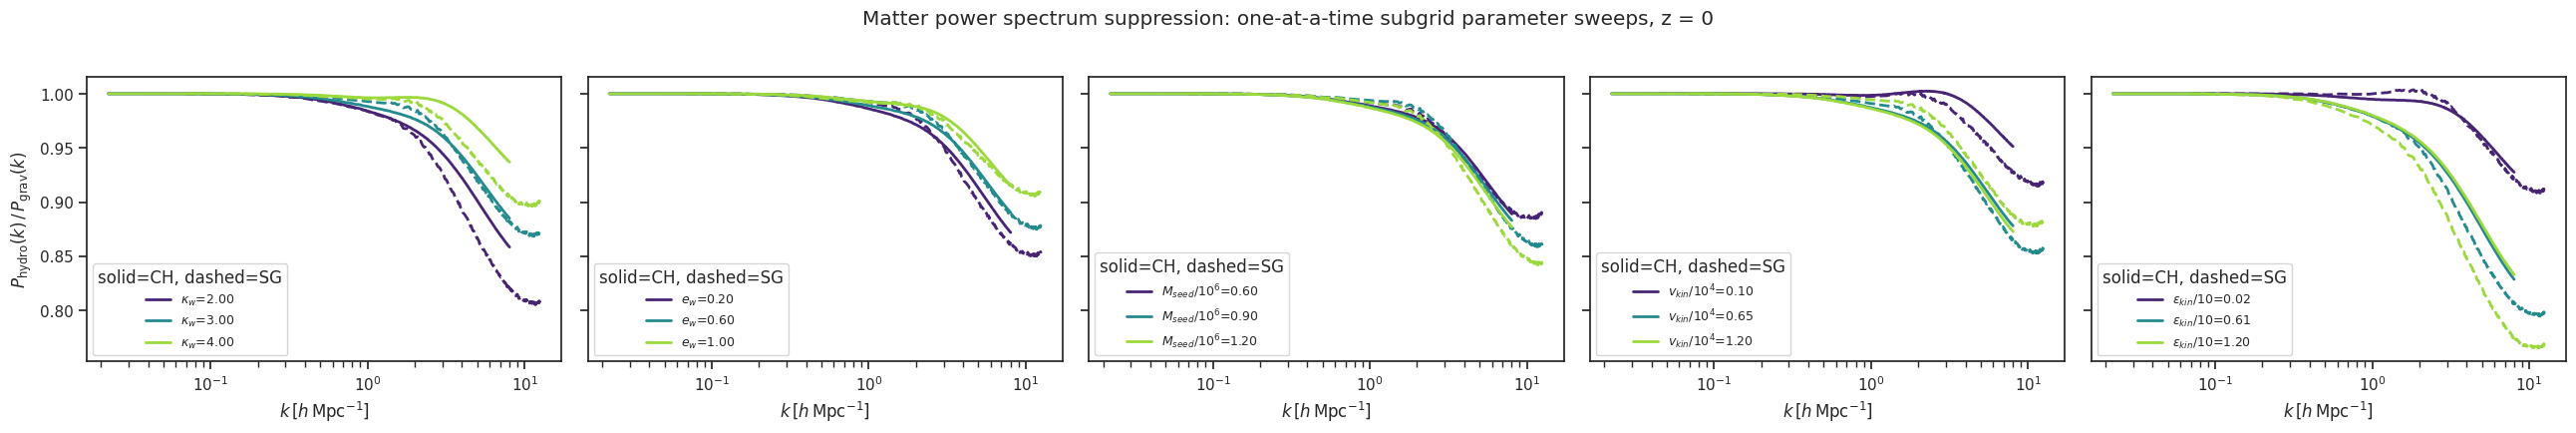

In [6]:
# common ranges: intersection of the two training boxes
SWEEP_RANGES = {0: (2.0, 4.0, r'$\kappa_w$'),
                1: (0.2, 1.0, r'$e_w$'),
                2: (0.6, 1.2, r'$M_{seed}/10^6$'),
                3: (0.1, 1.2, r'$v_{kin}/10^4$'),
                4: (0.02, 1.2, r'$\epsilon_{kin}/10$')}
N_SWEEP = 3

for stat_ch, stat_sg in [('GSMF', 'GSMF'), ('Pk-ratio', 'Pk')]:
    ch_emu = ce.load_emulator(stat_ch)
    sg_emu = sge.load_emulator(stat_sg)
    ch_x, _ = ce.get_x_grid(stat_ch)
    sg_x, _ = sge.get_x_grid(stat_sg)
    info = ce.get_plot_info(stat_ch)

    fig, axes = plt.subplots(1, 5, figsize=(26, 4.2), sharey=True)
    for i, (lo, hi, label) in SWEEP_RANGES.items():
        ax = axes[i]
        vals = np.linspace(lo, hi, N_SWEEP)
        colors = plt.cm.viridis(np.linspace(0.1, 0.85, N_SWEEP))
        for v, c in zip(vals, colors):
            p5 = list(P5); p5[i] = v
            p7 = p5 + [FP['omega_m'], FP['sigma_8']]
            m_ch, _ = ch_emu.predict(p7, z=0.0)
            m_sg, _ = sg_emu.predict(p5)
            ax.plot(ch_x, m_ch, color=c, lw=2, label=f'{label}={v:.2f}')
            ax.plot(sg_x, m_sg, color=c, lw=2, ls='--')
        ax.set_xscale(info['xscale']); ax.set_yscale(info['yscale'])
        ax.set_xlabel(info['xlabel'])
        ax.legend(fontsize=9, title='solid=CH, dashed=SG')
        if i == 0:
            ax.set_ylabel(info['ylabel'])
    plt.suptitle(f'{info["title"]}: one-at-a-time subgrid parameter sweeps, z = 0', y=1.03)
    plt.tight_layout(); plt.show()

## Calibration targets: how both emulators sit against the observations

The observational datasets used to calibrate the subgrid model (and shown in the
Inference_cosmo posterior-predictive panels) are loaded from
`../data_observational/` via `load_obs_data.py`: GAMA DR4 GSMF (Driver+22),
Kugel+23 gas fractions, and McDonald+17 / Ghirardini+19 / Lehle+23 cluster gas
density profiles.

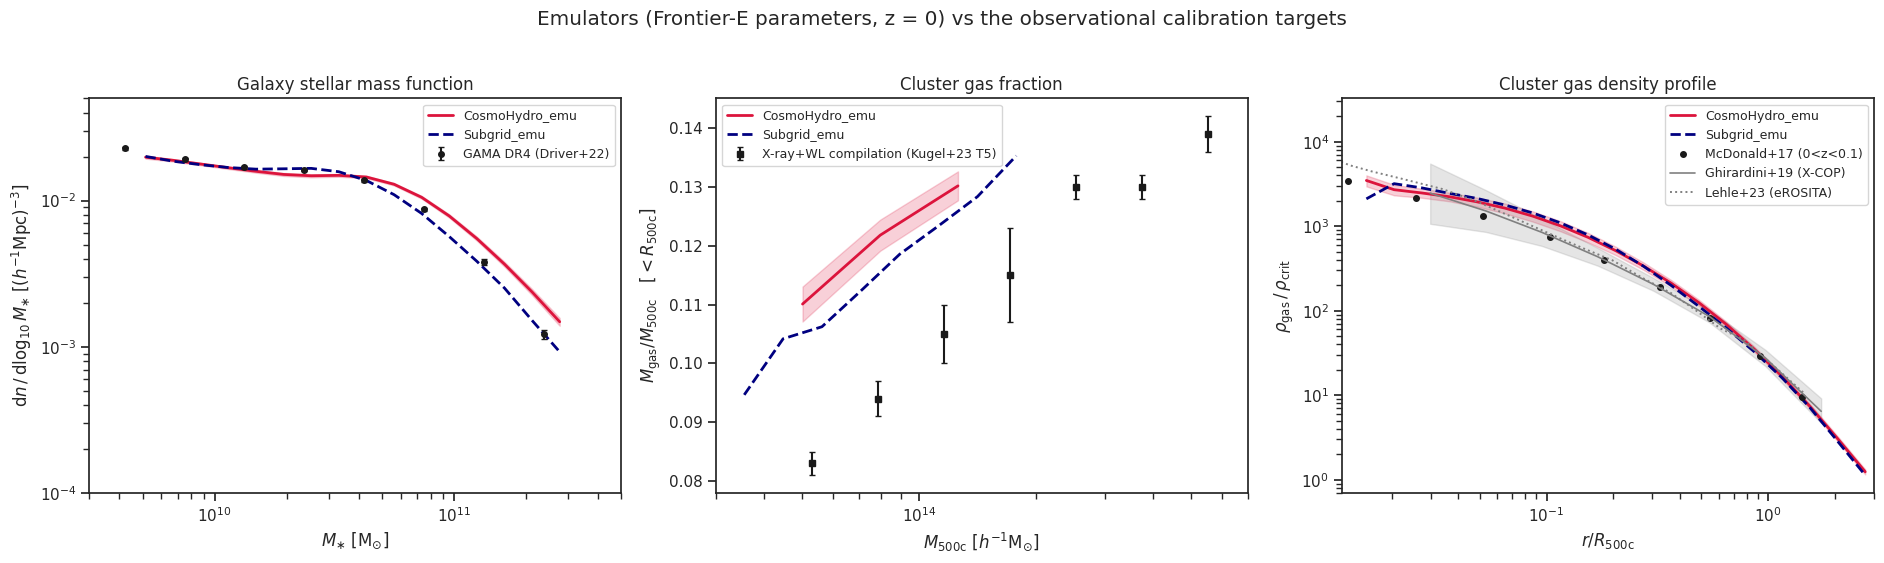

In [7]:
import sys
sys.path.insert(0, '../data_observational')
import load_obs_data as obs

gsmf_obs = obs.load_gsmf_driver2022()
fgas_obs = obs.load_fgas_kugel2023()
cgd_obs = obs.load_cgd_obs()

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for ax, ch_name in zip(axes, ['GSMF', 'fGas', 'CGD']):
    d = pred[ch_name]
    info = ce.get_plot_info(ch_name)
    ax.plot(d['ch_x'], d['ch_mean'], color='crimson', lw=2, label='CosmoHydro_emu')
    ax.fill_between(d['ch_x'], d['ch_mean'] - 2*d['ch_std'],
                    d['ch_mean'] + 2*d['ch_std'], color='crimson', alpha=0.2)
    ax.plot(d['sg_x'], d['sg_mean'], color='navy', lw=2, ls='--', label='Subgrid_emu')
    ax.set_xscale(info['xscale']); ax.set_yscale(info['yscale'])
    ax.set_title(info['title']); ax.set_xlabel(info['xlabel']); ax.set_ylabel(info['ylabel'])

axes[0].errorbar(gsmf_obs['x'], gsmf_obs['y'], yerr=gsmf_obs['yerr'], fmt='o', ms=4,
                 color='k', capsize=2, label=gsmf_obs['label'])
axes[0].set_xlim(3e9, 5e11); axes[0].set_ylim(1e-4, 5e-2)

axes[1].errorbar(fgas_obs['x'], fgas_obs['y'], yerr=fgas_obs['yerr'], fmt='s', ms=4,
                 color='k', capsize=2, label=fgas_obs['label'])
axes[1].set_xlim(3e13, 7e14)   # explicit: mpl autoscale misbehaves for errorbar on log axes

mc = cgd_obs['mcdonald2017']
axes[2].plot(mc['x'], mc['y'], 'o', ms=4, color='k', label=mc['label'])
gh = cgd_obs['ghirardini2019']
axes[2].plot(gh['x'], gh['y'], '-', color='gray', lw=1.2, label=gh['label'])
axes[2].fill_between(gh['x'], gh['y'] - gh['yerr'][0], gh['y'] + gh['yerr'][1],
                     color='gray', alpha=0.2)
le = cgd_obs['lehle2023']
axes[2].plot(le['x'], le['y'], ':', color='gray', lw=1.4, label=le['label'])
axes[2].set_xlim(1.2e-2, 3)

for ax in axes:
    ax.legend(fontsize=9)
plt.suptitle('Emulators (Frontier-E parameters, z = 0) vs the observational calibration targets', y=1.02)
plt.tight_layout(); plt.show()

## Notes

- The two packages emulate the *same physics model* (CRK-HACC subgrid prescription) but on
  **different simulation suites**: Subgrid_emu on 64×(128 h⁻¹Mpc, 2×512³) Phase-1 boxes
  (+16×256 h⁻¹Mpc 2p boxes), CosmoHydro_emu on 100×(400 h⁻¹Mpc, 2×1024³) boxes that
  additionally vary (ωₘ, σ₈).
- Residual differences therefore fold in: finite-volume / sample-variance differences
  (especially cluster statistics, fGas and CGD, where the 128 Mpc/h box has few clusters),
  resolution, and the different experimental designs (M_seed spans (0.6, 2.0) in CosmoHydro
  vs (0.6, 1.2) in Subgrid).
- The Pk-ratio k-grids differ (box-size dependent fundamental mode and Nyquist);
  ratios are shown on the overlapping k-range only.